# 从 `functional.conv2d` 到 `nn.Conv2d` 的 CNN 前向传播

## 作业目标

本次上机作业围绕 `torch.nn.functional.conv2d`、`nn.Conv2d` 和简单 CNN 前向传播展开。

本版本使用一张 `1024 × 1024` 的灰度图像，帮助你观察大尺寸图像经过卷积、池化和展平后的 shape 变化。

你需要完成 6 个任务：

1. 观察已给定的 `1024 × 1024` 灰度图像；
2. 使用 `F.conv2d` 完成手工卷积，并比较 padding 对输出尺寸的影响；
3. 使用 `nn.Conv2d` 创建可学习卷积层，并观察参数 shape；
4. 补全一个简单 CNN 的前向传播；
5. 修改网络结构，并修复 `Linear` 层输入维度；
6. 计算模型参数量并回答总结问题。

## 提交要求

所有需要补全的位置都使用：

```python
# TODO
```

请补全代码并运行所有单元格，确保没有报错。



## 准备：导入依赖并固定随机种子

运行下面代码，确保环境可用。

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.12.0+cpu


## 任务 1：观察已给定的灰度图像

### 背景说明

在 PyTorch 中，一张灰度图像通常表示为：

```python
[batch_size, channels, height, width]
```

例如：

```python
[1, 1, 1024, 1024]
```

表示：

- `batch_size = 1`：只有一张图片；
- `channels = 1`：灰度图；
- `height = 1024`；
- `width = 1024`。

下面的代码已经为你构造好一张简单的 `1024 × 1024` 灰度图像。你只需要运行并观察它。

In [2]:
# 已给定的 1024 × 1024 灰度图像，不需要同学们补全
image = torch.zeros(1024, 1024)

# 中间放一个白色正方形
image[256:768, 256:768] = 1.0

# 再添加一条灰色斜线，方便观察卷积效果
for i in range(128, 896):
    image[i, i] = 0.5

# 转换为 F.conv2d / nn.Conv2d 需要的 4D 输入格式：[batch_size, channels, height, width]
image_4d = image.unsqueeze(0).unsqueeze(0)

print("image shape:", image.shape)
print("image_4d shape:", image_4d.shape)

assert image_4d.shape == (1, 1, 1024, 1024), "image_4d 的 shape 应该是 [1, 1, 1024, 1024]"

image shape: torch.Size([1024, 1024])
image_4d shape: torch.Size([1, 1, 1024, 1024])


In [3]:
plt.figure(figsize=(4, 4))
plt.imshow(image_4d[0, 0].detach().cpu().numpy(), cmap="gray")
plt.title("Given 1024 x 1024 Gray Image")
plt.axis("off")
plt.savefig("image_preview.png")
plt.close()

## 任务 2：使用 `F.conv2d` 做手工卷积，并比较 padding

### 背景说明

`F.conv2d` 需要输入：

```python
input:  [batch_size, in_channels, height, width]
weight: [out_channels, in_channels, kernel_height, kernel_width]
```

对于一张灰度图像，如果只使用一个 `3 × 3` 卷积核，那么卷积核 shape 应该是：

```python
[1, 1, 3, 3]
```

### 你的任务

补全下面代码，完成：

1. 定义竖直边缘检测卷积核；
2. 将卷积核转换为 `[1, 1, 3, 3]`；
3. 分别使用 `padding=0` 和 `padding=1` 做卷积；
4. 观察输出 shape 和可视化结果。

竖直边缘检测卷积核：

```python
[[-1, 0, 1],
 [-1, 0, 1],
 [-1, 0, 1]]
```

In [4]:
# TODO: 定义 3 × 3 的竖直边缘检测卷积核
vertical_kernel_2d = torch.tensor([
    [[-1,0,1],
    [-1,0,1],
    [-1,0,1]]
], dtype=torch.float32)

# TODO: 将卷积核转换为 [1, 1, 3, 3]
vertical_kernel_4d = vertical_kernel_2d.unsqueeze(0)

# TODO: 使用 padding=0 做卷积
out_padding_0 = F.conv2d(image_4d,vertical_kernel_4d,stride=1,padding=0)

# TODO: 使用 padding=1 做卷积
out_padding_1 = F.conv2d(image_4d,vertical_kernel_4d,stride=1,padding=1)

print("kernel shape:", vertical_kernel_4d.shape)
print("padding=0 output shape:", out_padding_0.shape)
print("padding=1 output shape:", out_padding_1.shape)

assert vertical_kernel_4d.shape == (1, 1, 3, 3), "卷积核 shape 应该是 [1, 1, 3, 3]"
assert out_padding_0.shape == (1, 1, 1022, 1022), "padding=0 时，输出应该是 [1, 1, 1022, 1022]"
assert out_padding_1.shape == (1, 1, 1024, 1024), "padding=1 时，输出应该是 [1, 1, 1024, 1024]"

kernel shape: torch.Size([1, 1, 3, 3])
padding=0 output shape: torch.Size([1, 1, 1022, 1022])
padding=1 output shape: torch.Size([1, 1, 1024, 1024])


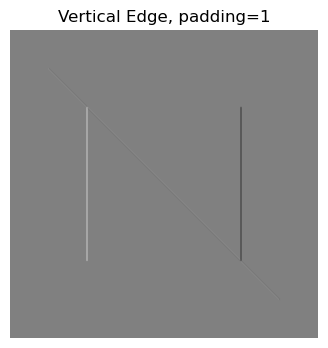

In [5]:
plt.figure(figsize=(4, 4))
plt.imshow(out_padding_1[0, 0].detach(), cmap="gray")
plt.title("Vertical Edge, padding=1")
plt.axis("off")
plt.show()

## 任务 3：使用 `nn.Conv2d` 创建可学习卷积层

### 背景说明

`F.conv2d` 更像是一个函数，需要你手动提供卷积核。

`nn.Conv2d` 是一个神经网络层，内部包含可学习参数：

- `weight`
- `bias`

例如：

```python
nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, padding=1)
```

表示输入是 1 个通道，输出是 4 个通道。也就是说，这一层会学习 4 个卷积核。

### 你的任务

补全下面代码，创建一个卷积层：

```python
in_channels=1
out_channels=4
kernel_size=3
padding=1
```

然后观察输入、输出、`weight` 和 `bias` 的 shape。

In [6]:
x = image_4d

# TODO: 创建 nn.Conv2d 层
conv = nn.Conv2d(
    in_channels= 1,
    out_channels= 4,
    kernel_size= 3,
    padding= 1
)

y = conv(x)

print("input shape:", x.shape)
print("output shape:", y.shape)
print("weight shape:", conv.weight.shape)
print("bias shape:", conv.bias.shape)

assert y.shape == (1, 4, 1024, 1024), "输出 shape 应该是 [1, 4, 1024, 1024]"
assert conv.weight.shape == (4, 1, 3, 3), "weight shape 应该是 [4, 1, 3, 3]"
assert conv.bias.shape == (4,), "bias shape 应该是 [4]"

input shape: torch.Size([1, 1, 1024, 1024])
output shape: torch.Size([1, 4, 1024, 1024])
weight shape: torch.Size([4, 1, 3, 3])
bias shape: torch.Size([4])


### 思考题 1

请在下面 Markdown 单元格中回答：

1. `conv.weight.shape = [4, 1, 3, 3]` 分别表示什么？

2. 为什么输入是 1 个通道，输出却变成了 4 个通道？

【请在这里填写你的回答】

1.con.weight.shape中的第一个参数代表的是输出通道数，1代表的是输入通道数，3*3代表的是一个平面上卷积核的大小
2.weight卷积核有四个，类似于使用四个卷积核分别对输入通道进行卷积，对应分别得到了四个输出矩阵填充到四个输出通道中去

## 任务 4：补全一个简单 CNN 的前向传播

### 网络结构

现在我们搭建一个简单 CNN，用于处理 `1024 × 1024` 的灰度图像。

```text
输入: [batch_size, 1, 1024, 1024]

Conv2d(1, 8, kernel_size=3, padding=1)
ReLU
MaxPool2d(2, 2)

Conv2d(8, 16, kernel_size=3, padding=1)
ReLU
MaxPool2d(2, 2)

Flatten
Linear(16 * 256 * 256, 10)

输出: [batch_size, 10]
```

### shape 变化

```text
[batch_size, 1, 1024, 1024]
-> [batch_size, 8, 1024, 1024]
-> [batch_size, 8, 512, 512]
-> [batch_size, 16, 512, 512]
-> [batch_size, 16, 256, 256]
-> [batch_size, 16 * 256 * 256]
-> [batch_size, 10]
```

### 你的任务

补全 `SimpleCNN` 的 `__init__` 和 `forward`，并运行后面的检查代码。

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # TODO: 第一层卷积：输入 1 个通道，输出 8 个通道，卷积核大小 3，padding=1
        self.conv1 = nn.Conv2d(in_channels=1,out_channels=8,kernel_size=3,padding=1)
        self.nf = nn.ReLU()

        # TODO: 第二层卷积：输入 8 个通道，输出 16 个通道，卷积核大小 3，padding=1
        self.conv2 = nn.Conv2d(in_channels=8,out_channels=16,kernel_size=3,padding=1)

        # TODO: 最大池化层，kernel_size=2, stride=2
        self.pool = nn.MaxPool2d(kernel_size=2,stride=2)

        # TODO: 全连接层，输入维度为 16 * 256 * 256，输出维度为 10
        self.fc = nn.Linear(16 * 256 * 256,10)

    def forward(self, x):
        # x: [batch_size, 1, 1024, 1024]

        # TODO: conv1 -> relu -> pool
        x = self.conv1(x)
        x = self.nf(x)
        x = self.pool(x)

        # TODO: conv2 -> relu -> pool
        x = self.conv2(x)
        x = self.nf(x)
        x = self.pool(x)

        # TODO: flatten，从第 1 维开始展平，保留 batch 维度 x.shape[0]
        x = x.view(x.shape[0],-1)

        # TODO: 全连接层
        x = self.fc(x)

        return x

In [8]:
model = SimpleCNN()

# 使用 batch_size=1，避免 1024 × 1024 图像占用过多内存
batch_x = torch.randn(1, 1, 1024, 1024)
out = model(batch_x)

print("input shape:", batch_x.shape)
print("output shape:", out.shape)

assert out.shape == (1, 10), "模型输出 shape 应该是 [1, 10]"

input shape: torch.Size([1, 1, 1024, 1024])
output shape: torch.Size([1, 10])


### 任务 4 续：打印每一层之后的 shape

为了理解 CNN 的前向传播，请补全下面函数，打印每一步之后的 shape。

In [9]:
def forward_with_shape(model, x):
    print("input:", x.shape)

    # TODO: conv1，并打印 shape
    x = model.conv1(x)
    print("after conv1:", x.shape)

    # TODO: relu + pool，并打印 shape
    x = model.nf(x)
    x = model.pool(x)
    print("after pool1:", x.shape)

    # TODO: conv2，并打印 shape
    x = model.conv2(x)
    print("after conv2:", x.shape)

    # TODO: relu + pool，并打印 shape
    x = model.nf(x)
    x = model.pool(x)
    print("after pool2:", x.shape)

    # TODO: flatten，并打印 shape
    x = x.view(x.shape[0],-1)
    print("after flatten:", x.shape)

    # TODO: fc，并打印 shape
    x = model.fc(x)
    print("after fc:", x.shape)

    return x

out2 = forward_with_shape(model, batch_x)

assert out2.shape == (1, 10), "forward_with_shape 的输出 shape 应该是 [1, 10]"

input: torch.Size([1, 1, 1024, 1024])
after conv1: torch.Size([1, 8, 1024, 1024])
after pool1: torch.Size([1, 8, 512, 512])
after conv2: torch.Size([1, 16, 512, 512])
after pool2: torch.Size([1, 16, 256, 256])
after flatten: torch.Size([1, 1048576])
after fc: torch.Size([1, 10])


## 任务 5：修改网络结构并修复 `Linear` 输入维度

### 背景说明

如果你修改了卷积层的输出通道数，或者修改了池化层数量，那么进入 `Linear` 层之前的特征维度通常也会发生变化。

常见报错：

```text
RuntimeError: mat1 and mat2 shapes cannot be multiplied
```

这通常说明：

```python
nn.Linear(in_features, out_features)
```

中的 `in_features` 写错了。

### 你的任务

下面包含两个小网络：

1. `BiggerCNN`：把通道数变大；
2. `OnePoolCNN`：只使用一次池化。

请分别补全 `nn.Linear(..., 10)` 的输入维度。

In [10]:
class BiggerCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # TODO: 两次池化：1024 -> 512 -> 256
        # 最终 shape: [batch_size, 32, 256, 256]
        self.fc = nn.Linear(32*256*256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x


class OnePoolCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # TODO: 只池化一次：1024 -> 512
        # 最终 shape: [batch_size, 16, 512, 512]
        self.fc = nn.Linear(16*512*512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = F.relu(self.conv2(x))
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x


bigger_model = BiggerCNN()
one_pool_model = OnePoolCNN()

bigger_out = bigger_model(batch_x)
one_pool_out = one_pool_model(batch_x)

print("BiggerCNN output shape:", bigger_out.shape)
print("OnePoolCNN output shape:", one_pool_out.shape)

assert bigger_out.shape == (1, 10), "BiggerCNN 输出 shape 应该是 [1, 10]"
assert one_pool_out.shape == (1, 10), "OnePoolCNN 输出 shape 应该是 [1, 10]"

BiggerCNN output shape: torch.Size([1, 10])
OnePoolCNN output shape: torch.Size([1, 10])


## 任务 6：计算参数量并完成总结

### 背景说明

对于一个卷积层：

```python
nn.Conv2d(in_channels, out_channels, kernel_size)
```

参数量为：

```text
out_channels × in_channels × kernel_height × kernel_width + out_channels
```

其中最后的 `out_channels` 来自 bias。

例如：

```python
nn.Conv2d(1, 8, kernel_size=3)
```

参数量是：

```text
8 × 1 × 3 × 3 + 8 = 80
```

### 你的任务

补全函数 `count_parameters`，计算模型总参数量。

注意：由于本版本输入图像是 `1024 × 1024`，如果直接 flatten 后接全连接层，`Linear` 层的参数量会非常大。

In [11]:
def count_parameters(model):
    total = 0

    # TODO: 遍历模型中的所有参数，并累加参数数量
    # 提示：p.numel() 可以返回一个参数张量中的元素个数
    for p in model.parameters():
        total += p.numel()

    return total

simple_params = count_parameters(model)
bigger_params = count_parameters(bigger_model)
one_pool_params = count_parameters(one_pool_model)

print("SimpleCNN parameters:", simple_params)
print("BiggerCNN parameters:", bigger_params)
print("OnePoolCNN parameters:", one_pool_params)

assert simple_params > 0, "参数量应该大于 0"
assert bigger_params > simple_params, "BiggerCNN 的参数量通常应该大于 SimpleCNN"

SimpleCNN parameters: 10487018
BiggerCNN parameters: 20976330
OnePoolCNN parameters: 41944298


### 总结题

请在下面 Markdown 单元格中回答：

1. `F.conv2d` 和 `nn.Conv2d` 的主要区别是什么？
2. `nn.Conv2d` 中 `in_channels` 和 `out_channels` 分别是什么意思？
3. 为什么进入 `nn.Linear` 之前通常需要 `torch.flatten`？
4. 如果出现 `mat1 and mat2 shapes cannot be multiplied`，你会如何排查？
5. 当输入图像从 `28 × 28` 增大到 `1024 × 1024` 后，为什么全连接层参数量会急剧增加？

【请在这里填写你的回答】

1. 主要区别在于卷积核，在F.conv2d中卷积核是一个确定的输入矩阵，但在nn.Conv2d中则是一个待求参数的矩阵
2. nn.Conv2d中的输入维度是指的输入图像的通道数，out_channels则是指输出通道数
3. 因为nn.Linear是连接从n * 1 到 m * 1维矩阵的线性变化，需要把参数拍成一维的参数以供处理
4. 检查nn.Linear的输入层参数的数量和实际输入的不符合，需要确认输入的参数数量
5. 因为全连接层的参数数量为n * m （无bias），而28 * 28时n为784，1024 *1024时，n为1048576，对应的n * m的值也随之增大。